<a href="https://colab.research.google.com/github/Mayar215999/data-science-project/blob/main/Classify_Waste_Products_Using_Transfer_Learning_Deep_learning_M7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practice Project: Fruit Classification Using Transfer Learning
Estimated Time Needed: 90 minutes

Setup instructions
Prerequisites
Basic knowledge of Python and Keras.

TensorFlow installed in your Python environment.

A data set of fruit images organized in subdirectories for each class.


code to suppress warnings

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.trainers.data_adapters.py_dataset_adapter")
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.trainers.epoch_iterator")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress all warnings and info messages

In [2]:
!pip install tensorflow==2.16.2
!pip install matplotlib==3.9.2
!pip install numpy==1.26.4
!pip install scipy==1.14.1
!pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.7/590.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.7 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow

In [14]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.trainers.data_adapters.py_dataset_adapter")
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.trainers.epoch_iterator")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings

# Install required libraries
!pip install tensorflow==2.16.2
!pip install matplotlib==3.9.2
!pip install numpy==1.26.4
!pip install scipy==1.14.1
!pip install scikit-learn==1.5.2


In [23]:
import os

# Define the dataset path in Google Drive
dataset_path = "/content/drive/MyDrive/dataset/"

# Define subdirectories
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

# Check if directories exist and list class folders
if os.path.exists(train_path):
    print("Train Classes:", os.listdir(train_path))
else:
    print("Train directory not found!")

if os.path.exists(val_path):
    print("Validation Classes:", os.listdir(val_path))
else:
    print("Validation directory not found!")

if os.path.exists(test_path):
    print("Test Classes:", os.listdir(test_path))
else:
    print("Test directory not found!")


Train directory not found!
Validation directory not found!
Test directory not found!


In [ ]:
dataset_path = "/content/drive/MyDrive/dataset/"
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

# Check if dataset is correctly loaded
print("Train Classes:", os.listdir(train_path))
print("Validation Classes:", os.listdir(val_path))
print("Test Classes:", os.listdir(test_path))


Data prepration

Tasks List
To achieve the above objectives, you will complete the following tasks:

Task 1: Import necessary libraries and set dataset paths
Task 2: Set up data generators for training, validation, and testing with augmentation
Task 3: Define the VGG16-based model architecture with custom layers
Task 4: Compile the model with appropriate loss and optimizer
Task 5: Train the model with early stopping and learning rate scheduling
Task 6: Fine-tune the model by unfreezing specific layers in VGG16
Task 7: Evaluate the model on the test set and display accuracy
Task 8: Visualize training performance with accuracy and loss curves
Task 9: Test model predictions on sample images and visualize results

Download the input data file
Note: The dataset download may take up to 30 minutes depending on your internet connection. Please ensure a stable connection and wait until the download completes.

In [24]:
import os
import subprocess
import zipfile

# Define dataset URL and paths
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip"
local_zip = "fruits-360-original-size.zip"
extract_dir = "fruits-360-original-size"

def download_dataset(url, output_file):
    """Download the dataset using wget in quiet mode."""
    print("Downloading the dataset...")
    subprocess.run(["wget", "-q", "-O", output_file, url], check=True)  # Add `-q` for quiet mode
    print("Download completed.")

def extract_zip_in_chunks(zip_file, extract_to, batch_size=2000):
    """
    Extract a large zip file in chunks to avoid memory bottlenecks.
    Processes a specified number of files (batch_size) at a time.
    """
    print("Extracting the dataset in chunks...")
    os.makedirs(extract_to, exist_ok=True)  # Ensure the extraction directory exists

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        files = zip_ref.namelist()  # List all files in the archive
        total_files = len(files)

        for i in range(0, total_files, batch_size):
            batch = files[i:i+batch_size]
            for file in batch:
                zip_ref.extract(file, extract_to)  # Extract each file in the batch
            print(f"Extracted {min(i+batch_size, total_files)} of {total_files} files...")

    print(f"Dataset successfully extracted to '{extract_to}'.")

# Main script execution
if __name__ == "__main__":
    # Download the dataset if not already downloaded
    if not os.path.exists(local_zip):
        download_dataset(url, local_zip)
    else:
        print("Dataset already downloaded.")

    # Extract the dataset if not already extracted
    if not os.path.exists(extract_dir):
        extract_zip_in_chunks(local_zip, extract_dir)
    else:
        print("Dataset already extracted.")

    # Optional cleanup of the zip file
    if os.path.exists(local_zip):
        os.remove(local_zip)
        print(f"Cleaned up zip file: {local_zip}")

Download completed.
Extracting the dataset in chunks...
Extracted 2000 of 12481 files...
Extracted 4000 of 12481 files...
Extracted 6000 of 12481 files...
Extracted 8000 of 12481 files...
Extracted 10000 of 12481 files...
Extracted 12000 of 12481 files...
Extracted 12481 of 12481 files...
Dataset successfully extracted to 'fruits-360-original-size'.
Cleaned up zip file: fruits-360-original-size.zip


Note: If you see warnings related to GPU (e.g., CUDA or cuDNN), it means the system is running on the CPU. Training may take longer.
Task 1: Import necessary libraries and set dataset paths
Explanation: This task involves importing essential libraries and setting up the paths for the dataset directories (train, val, and test). These libraries are necessary for data handling, model building, and performance evaluation.

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Set dataset paths
train_dir = 'fruits-360-original-size/fruits-360-original-size/Training'
val_dir = 'fruits-360-original-size/fruits-360-original-size/Validation'
test_dir = 'fruits-360-original-size/fruits-360-original-size/Test'

Library Explanations:
ImageDataGenerator: For loading images and applying data augmentation.
VGG16: Pre-trained model used for transfer learning.
Sequential: For building a sequential model.
Dense, Flatten, Dropout, BatchNormalization: Layers to customize the model architecture.
ReduceLROnPlateau, EarlyStopping: Callbacks for optimizing training.
Task 2: Set up data generators for training, validation, and testing with augmentation
Explanation: Data generators load images from directories, rescale them, and apply augmentation on the training set to help the model generalize better. Validation and test sets are only rescaled (no augmentation).

In [26]:
# Image data generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=16,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=16,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=16,
    class_mode='categorical'
)

Found 6231 images belonging to 24 classes.
Found 3114 images belonging to 24 classes.
Found 3110 images belonging to 24 classes.


Explanation:
train_datagen: Applies rescaling and augmentation (e.g., rotation, zoom) to make the model more robust.
val_datagen and test_datagen: Only rescale images for validation/testing.
flow_from_directory: Loads images from specified folders into batches for training/validation/testing.
Task 3: Define the VGG16-based model architecture with custom layers
Explanation: This task involves loading the pre-trained VGG16 model (excluding the top layers) and adding custom layers to adapt it to the fruit classification task.

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout

# Load VGG16 with pre-trained weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Explanation:
base_model: Loads VGG16, excluding its dense layers (include_top=False).
for layer in base_model.layers: Freezes VGG16 layers to retain pre-trained weights.
Custom layers: Flatten the output, then add dense layers with regularization (Dropout) and normalization (BatchNormalization) to enhance learning.
Task 4: Compile the model with appropriate loss and optimizer
Explanation: Compile the model to specify the loss function, optimizer, and evaluation metric.

In [29]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Explanation:
categorical_crossentropy: Used because this is a multi-class classification task.
adam: Adaptive learning rate optimizer that helps in faster convergence.
metrics=['accuracy']: Tracks model accuracy.
Task 5: Train the model with early stopping and learning rate scheduling
Explanation: Train the model, using callbacks to monitor the validation loss and adjust the learning rate or stop early to prevent overfitting.

In [30]:
import tensorflow as tf
from tensorflow.keras.mixed_precision import set_global_policy

# Define callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Enable mixed precision (if on GPU)
set_global_policy('float32')

steps_per_epoch = 50
validation_steps = 25

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.1581 - loss: 3.0795 - val_accuracy: 0.2100 - val_loss: 2.6393 - learning_rate: 0.0010
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.4986 - loss: 1.7262 - val_accuracy: 0.4150 - val_loss: 2.1833 - learning_rate: 0.0010
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5552 - loss: 1.4022 - val_accuracy: 0.4075 - val_loss: 1.8792 - learning_rate: 0.0010
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6781 - loss: 1.0819 - val_accuracy: 0.7125 - val_loss: 1.3574 - learning_rate: 0.0010
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7128 - loss: 0.8953 - val_accuracy: 0.6600 - val_loss: 1.2278 - learning_rate: 0.0010


Explanation:
ReduceLROnPlateau: Reduces learning rate when validation loss plateaus, allowing better optimization.
EarlyStopping: Stops training when validation loss no longer improves, preventing overfitting.
model.fit: Trains the model on the train_generator and evaluates on val_generator each epoch.
Task 6: Fine-tune the model by unfreezing specific layers in VGG16
Explanation: Fine-tune by unfreezing a few layers in the VGG16 base model to allow learning on fruit-specific features.

Note: Fine-tuning may take excess time on a CPU-based machine.

In [31]:
# Import necessary libraries
import tensorflow as tf  # Import TensorFlow for accessing tf.keras
from tensorflow.keras.optimizers import Adam

# Check the number of layers in the base model
num_layers = len(base_model.layers)
print(f"The base model has {num_layers} layers.")

# Unfreeze the last 5 layers for fine-tuning
for layer in base_model.layers[-5:]:
    layer.trainable = True

# Freeze BatchNorm layers to speed up fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile the model with a faster optimizer
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # Higher learning rate for faster convergence
    metrics=['accuracy']
)

# Continue training with fewer steps per epoch
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,  # Reduced steps per epoch
    validation_steps=validation_steps,  # Reduced validation steps
    callbacks=[lr_scheduler, early_stopping]
)

The base model has 19 layers.
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7115 - loss: 0.8634 - val_accuracy: 0.7300 - val_loss: 0.9095 - learning_rate: 1.0000e-05
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7751 - loss: 0.6828 - val_accuracy: 0.8050 - val_loss: 0.7285 - learning_rate: 1.0000e-05
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8022 - loss: 0.6790 - val_accuracy: 0.8375 - val_loss: 0.4958 - learning_rate: 1.0000e-05
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8430 - loss: 0.5702 - val_accuracy: 0.8925 - val_loss: 0.4613 - learning_rate: 1.0000e-05
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8404 - loss: 0.5276 - val_accuracy: 0.8875 - val_loss: 0.3771 - learning_rate: 1.0000e-05


Explanation
for layer in base_model.layers[-5:]: Unfreezes the last 5 layers to allow fine-tuning.
Unfreezing fewer layers is faster and prevents overfitting on small datasets.
RMSprop(learning_rate=1e-5): Optimizer with a lower learning rate to fine-tune carefully without drastic weight changes.
Task 7: Evaluate the model on the test set and display accuracy
Explanation: Evaluates the final model on unseen test data to gauge its generalization.

In [32]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=50)
print(f"Test Accuracy: {test_accuracy:.2f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 667ms/step - accuracy: 0.8995 - loss: 0.3333
Test Accuracy: 0.90


Explanation:
model.evaluate(test_generator): Evaluates the model on the test set and prints accuracy, giving a final measure of model performance.
Task 8: Visualize training performance with accuracy and loss curves
Explanation: Plots the training and validation accuracy and loss to understand the model’s learning progress.

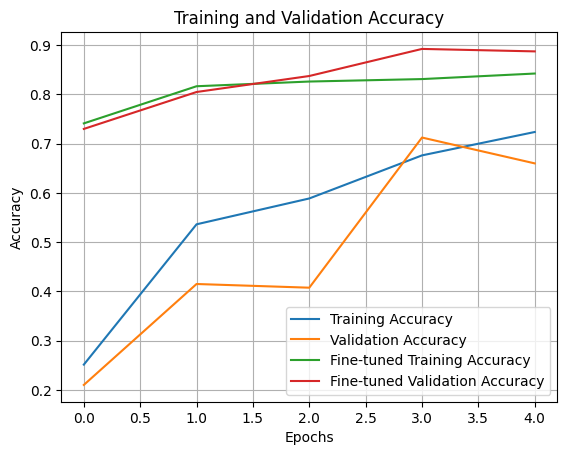

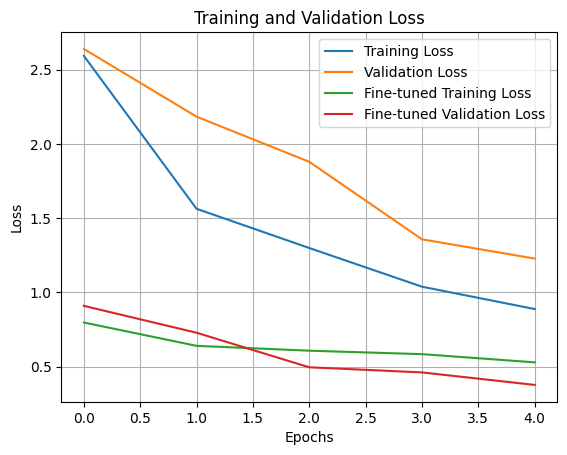

In [33]:
# Plot accuracy and loss curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_fine.history['accuracy'], label='Fine-tuned Training Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Fine-tuned Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history_fine.history['loss'], label='Fine-tuned Training Loss')
plt.plot(history_fine.history['val_loss'], label='Fine-tuned Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

Explanation:
plt.plot: Plots the accuracy and loss for training and validation over epochs.

Visual comparison shows if the model is overfitting, underfitting, or learning effectively.

Task 9: Test model predictions on sample images and visualize results
Explanation: Makes predictions on a few test images and displays them with the model's predicted class.

Class Index Mapping: {'apple_6': 0, 'apple_braeburn_1': 1, 'apple_crimson_snow_1': 2, 'apple_golden_1': 3, 'apple_golden_2': 4, 'apple_golden_3': 5, 'apple_granny_smith_1': 6, 'apple_hit_1': 7, 'apple_pink_lady_1': 8, 'apple_red_1': 9, 'apple_red_2': 10, 'apple_red_3': 11, 'apple_red_delicios_1': 12, 'apple_red_yellow_1': 13, 'apple_rotten_1': 14, 'cabbage_white_1': 15, 'carrot_1': 16, 'cucumber_1': 17, 'cucumber_3': 18, 'eggplant_violet_1': 19, 'pear_1': 20, 'pear_3': 21, 'zucchini_1': 22, 'zucchini_dark_1': 23}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


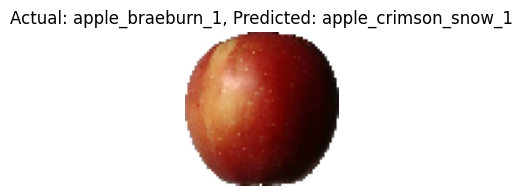

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


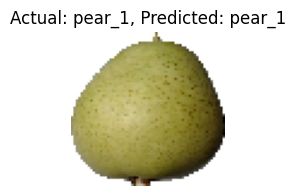

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


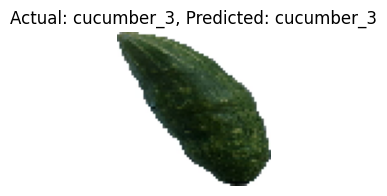

In [34]:
import os
import numpy as np
from collections import Counter
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import matplotlib.pyplot as plt

# Initialize counters for actual and predicted classes
actual_count = Counter()
predicted_count = Counter()

# Function to get class name from predicted index
def get_class_name_from_index(predicted_index, class_index_mapping):
    """Convert predicted index to class name."""
    for class_name, index in class_index_mapping.items():
        if index == predicted_index:
            return class_name
    return "Unknown"  # Default if index is not found

# Define the function for visualization
def visualize_prediction_with_actual(img_path, class_index_mapping):
    # Extract the true label dynamically from the directory structure
    class_name = os.path.basename(os.path.dirname(img_path))  # Extract folder name (class)

    # Load and preprocess the image
    img = load_img(img_path, target_size=(64, 64))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict the class
    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction, axis=-1)[0]
    predicted_class_name = get_class_name_from_index(predicted_index, class_index_mapping)

    # Update the counters
    actual_count[class_name] += 1
    predicted_count[predicted_class_name] += 1

    # Visualize the image with predictions
    plt.figure(figsize=(2, 2), dpi=100)
    plt.imshow(img)
    plt.title(f"Actual: {class_name}, Predicted: {predicted_class_name}")
    plt.axis('off')
    plt.show()

# Retrieve class index mapping from the training generator
class_index_mapping = train_generator.class_indices
print("Class Index Mapping:", class_index_mapping)  # Debugging: Check the mapping

# Define a list of image paths without hardcoded labels
sample_images = [
    'fruits-360-original-size/fruits-360-original-size/Test/apple_braeburn_1/r0_11.jpg',
    'fruits-360-original-size/fruits-360-original-size/Test/pear_1/r0_103.jpg',
    'fruits-360-original-size/fruits-360-original-size/Test/cucumber_3/r0_103.jpg',
]

# Run the predictions and visualization
for img_path in sample_images:
    visualize_prediction_with_actual(img_path, class_index_mapping)

Explanation:
visualize_prediction: Loads an image, preprocesses it, predicts its class, and displays it.

model.predict(img_array): Uses the trained model to make predictions on unseen images.

If there is an incorrect prediction during testing, the following factors could contribute to the misclassification:
Class Similarity: Visually similar fruit classes (e.g., apple types) can confuse the model.

Insufficient Data: Imbalanced datasets with fewer samples for certain classes may cause underfitting.

Limited Training: Fine-tuning fewer layers might not capture sufficient class-specific features.

Data Augmentation Impact: Aggressive augmentations may distort key features, reducing accuracy for specific images.

Conclusion
In this lab, you implemented a fruit classification model using transfer learning with VGG16. By fine-tuning and using data augmentation, you developed a robust classifier that can recognize different fruits. This lab demonstrated the efficiency of transfer learning in achieving high accuracy with minimal training data.

lab 2

Final Project: Classify Waste Products Using Transfer Learning


Estimated Time Needed: 60 minutes.

Table of contents

Classify Waste Products Using Transfer Learning
Introduction
Project Overview
Aim of the Project
Objectives
Tasks List
Sample Task: Sample screenshot showing code and output
Setup
Installing Required Libraries
Importing Required Libraries
Task 1: Print the version of tensorflow
Background
Create a model for distinguishing recyclable and organic waste images
Dataset
Importing Data
Define configuration options
Loading Images using ImageGeneratorClass
ImageDataGenerators
Task 2: Create a test_generator using the test_datagen object
Task 3: Print the length of the train_generator
Pre-trained Models
VGG-16
Task 4: Print the summary of the model
Task 5: Compile the model
Fit and train the model
Plot loss curves for training and validation sets (extract_feat_model)
Task 6: Plot accuracy curves for training and validation sets (extract_feat_model)
Fine-Tuning model
Task 7: Plot loss curves for training and validation sets (fine tune model)
Task 8: Plot accuracy curves for training and validation sets (fine tune model)
Evaluate both models on test data
Task 9: Plot a test image using Extract Features Model (index_to_plot = 1)
Task 10: Plot a test image using Fine-Tuned Model (index_to_plot = 1)
Authors
Introduction
In this project, you will classify waste products using transfer learning.

Project Overview
EcoClean currently lacks an efficient and scalable method to automate the waste sorting process. The manual sorting of waste is not only labor-intensive but also prone to errors, leading to contamination of recyclable materials. The goal of this project is to leverage machine learning and computer vision to automate the classification of waste products, improving efficiency and reducing contamination rates. The project will use transfer learning with a pre-trained VGG16 model to classify images.

Aim of the Project
The aim of the project is to develop an automated waste classification model that can accurately differentiate between recyclable and organic waste based on images. By the end of this project, you will have trained, fine-tuned, and evaluated a model using transfer learning, which can then be applied to real-world waste management processes.

Final Output: A trained model that classifies waste images into recyclable and organic categories.


Learning Objectives
After you complete the project, you will be able to:

Apply transfer learning using the VGG16 model for image classification.
Prepare and preprocess image data for a machine learning task.
Fine-tune a pre-trained model to improve classification accuracy.
Evaluate the model’s performance using appropriate metrics.
Visualize model predictions on test data.
By completing these objectives, you will be able to apply the techniques in real-world scenarios, such as automating waste sorting for municipal or industrial use.

Tasks List
To achieve the above objectives, you will complete the following tasks:

Task 1: Print the version of tensorflow
Task 2: Create a test_generator using the test_datagen object
Task 3: Print the length of the train_generator
Task 4: Print the summary of the model
Task 5: Compile the model
Task 6: Plot accuracy curves for training and validation sets (extract_feat_model)
Task 7: Plot loss curves for training and validation sets (fine tune model)
Task 8: Plot accuracy curves for training and validation sets (fine tune model)
Task 9: Plot a test image using Extract Features Model (index_to_plot = 1)
Task 10: Plot a test image using Fine-Tuned Model (index_to_plot = 1)
Note: For each task, take a screenshot of the code and the output and upload it in a folder with your name.





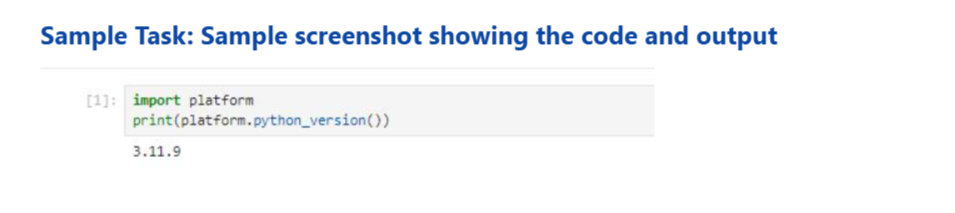

Setup
For this lab, you will be using the following libraries:

numpy for mathematical operations.
sklearn for machine learning and machine-learning-pipeline related functions.
matplotlib for additional plotting tools.
tensorflow for machine learning and neural network related functions.
Installing Required Libraries

In [36]:
# Upgrade pip and remove conflicting packages
!pip install --upgrade pip
!pip uninstall -y tensorflow tensorflow-text tf-keras numpy scipy scikit-learn gensim langchain pymc blosc2 albumentations treescope albucore

# Install compatible versions of dependencies
!pip install tensorflow==2.18.0 tensorflow-text==2.18.1 tf-keras==2.18.0
!pip install numpy==1.26.4 scipy==1.13.0
!pip install matplotlib==3.9.2 scikit-learn==1.5.1
!pip install gensim langchain pymc blosc2 albumentations treescope albucore


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: tensorflow 2.17.0
Uninstalling tensorflow-2.17.0:
  Successfully uninstalled tensorflow-2.17.0
Found existing installation: tensorflow-text 2.18.1
Uninstalling tensorflow-text-2.18.1:
  Successfully uninstalled tensorflow-text-2.18.1
Found existing installation: tf_keras 2.18.0
Uninstalling tf_keras-2.18.0:
  Successfully uninstalled tf_keras-2.18.0
Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Successfully uninstalled scipy-1.14.1
Found existing installation: scikit-learn 1.5.1
Uninstalling scikit-learn-1.5.1:
  Successfully uninstalled scikit-learn-1.5.1
Found existing installation: gensim 4.3.3
Uninstalling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 47.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, which is not installed.
tables 3.10.2 requires blosc2>=2.3.0, which is not installed.
umap-learn 0.5.7 requires scikit-learn>=0.22, which is not installed.
sentence-transformers 3.4.1 requires scikit-learn, which is not installed.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, which is not installed.
fastai 2.7.18 requires scikit-learn, which is not installed.
hdbscan 0.8.40 requires scikit-learn>=0.20, which is not installed.
yellowbrick 1.5 requires scikit-l

In [37]:
import numpy as np
import os
# import random, shutil
import glob


from matplotlib import pyplot as plt
from matplotlib import pyplot
from matplotlib.image import imread

# from os import makedirs,listdir
# from shutil import copyfile
# from random import seed
# from random import random

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# from tensorflow.keras.layers import Conv2D, MaxPooling2D,GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications import InceptionV3
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

Task 1: Print the version of tensorflow¶
Upload the screenshot of the version of tensorflow named tensorflow_version.png.

Hint: Use tf.__version__ to print the version of tensorflow.

TensorFlow Version: 2.16.2


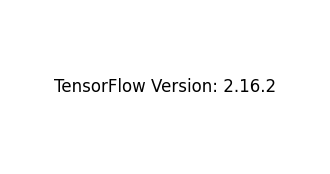

In [38]:
import tensorflow as tf

# Print TensorFlow version
print("TensorFlow Version:", tf.__version__)

# Save the output as an image
import matplotlib.pyplot as plt

# Create a blank figure
fig, ax = plt.subplots(figsize=(4, 2))
ax.text(0.5, 0.5, f"TensorFlow Version: {tf.__version__}", fontsize=12, ha='center', va='center')
ax.set_axis_off()

# Save the figure as an image
plt.savefig("tensorflow_version.png", bbox_inches='tight')
plt.show()


In [39]:
from google.colab import files
files.download("tensorflow_version.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Background
Transfer learning uses the concept of keeping the early layers of a pre-trained network, and re-training the later layers on a specific dataset. You can leverage some state of that network on a related task.

A typical transfer learning workflow in Keras looks something like this:

Initialize base model, and load pre-trained weights (e.g. ImageNet)
"Freeze" layers in the base model by setting training = False
Define a new model that goes on top of the output of the base model's layers.
Train resulting model on your data set.
Create a model for distinguishing recyclable and organic waste images
Dataset
You will be using the Waste Classification Dataset.

Your goal is to train an algorithm on these images and to predict the labels for images in your test set (1 = recyclable, 0 = organic).

Importing Data
This will create a o-vs-r-split directory in your environment.

In [40]:
import requests
import zipfile
from tqdm import tqdm

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip"
file_name = "o-vs-r-split-reduced-1200.zip"

print("Downloading file")
with requests.get(url, stream=True) as response:
    response.raise_for_status()
    with open(file_name, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)


def extract_file_with_progress(file_name):
    print("Extracting file with progress")
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        members = zip_ref.infolist()
        with tqdm(total=len(members), unit='file') as progress_bar:
            for member in members:
                zip_ref.extract(member)
                progress_bar.update(1)
    print("Finished extracting file")


extract_file_with_progress(file_name)

print("Finished extracting file")
os.remove(file_name)

Extracting file with progress


100%|██████████| 1207/1207 [00:00<00:00, 5322.55file/s]

Finished extracting file
Finished extracting file


Define configuration options
It's time to define some model configuration options.

batch size is set to 32.
The number of classes is 2.
You will use 20% of the data for validation purposes.
You have two labels in your dataset: organic (O), recyclable (R).

In [41]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
n_classes = 2
val_split = 0.2
verbosity = 1
path = 'o-vs-r-split/train/'
path_test = 'o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3)
labels = ['O', 'R']
seed = 42

Loading Images using ImageGeneratorClass
Transfer learning works best when models are trained on smaller datasets.

The folder structure looks as follows:

o-vs-r-split/
└── train
    ├── O
    └── R
└── test
    ├── O
    └── R
ImageDataGenerators
Now you will create ImageDataGenerators used for training, validation and testing.

Image data generators create batches of tensor image data with real-time data augmentation. The generators loop over the data in batches and are useful in feeding data to the training process.

In [42]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [43]:
train_generator = train_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size,
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'training'
)

Found 800 images belonging to 2 classes.


In [44]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size,
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'validation'
)

Found 200 images belonging to 2 classes.


Task 2: Create a test_generator using the test_datagen object¶
Upload the screenshot of the code and the output of the test generator as test_generator.png.

Please use the following parameters:

directory should be set to path_test.
class_mode should be set to 'binary'.
seed should be set to seed.
batch_size should be set to batch_size.
shuffle should be set to False.
target_size should be set to (img_rows, img_cols).
Hint: the format should be like:

test_generator = test_datagen.flow_from_directory(
    directory=,
    class_mode=,
    seed=,
    batch_size=,
    shuffle=,
    target_size=

In [56]:
for root, dirs, files in os.walk(".", topdown=True):
    print(root)


.
./.config
./.config/configurations
./.config/logs
./.config/logs/2025.02.27
./fruits-360-original-size
./fruits-360-original-size/fruits-360-original-size
./fruits-360-original-size/fruits-360-original-size/Test
./fruits-360-original-size/fruits-360-original-size/Test/carrot_1
./fruits-360-original-size/fruits-360-original-size/Test/apple_pink_lady_1
./fruits-360-original-size/fruits-360-original-size/Test/cucumber_1
./fruits-360-original-size/fruits-360-original-size/Test/apple_red_2
./fruits-360-original-size/fruits-360-original-size/Test/pear_1
./fruits-360-original-size/fruits-360-original-size/Test/apple_golden_2
./fruits-360-original-size/fruits-360-original-size/Test/apple_golden_1
./fruits-360-original-size/fruits-360-original-size/Test/apple_6
./fruits-360-original-size/fruits-360-original-size/Test/zucchini_1
./fruits-360-original-size/fruits-360-original-size/Test/apple_granny_smith_1
./fruits-360-original-size/fruits-360-original-size/Test/apple_crimson_snow_1
./fruits-36

In [65]:
import os

file_name = "o-vs-r-split-reduced-1200.zip"

if os.path.exists(file_name):
    print(f"✅ Found ZIP file: {file_name}")
else:
    print("❌ ZIP file NOT found. Re-downloading...")


✅ Found ZIP file: o-vs-r-split-reduced-1200.zip


In [64]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip


--2025-03-03 05:17:14--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11044622 (11M) [application/zip]
Saving to: ‘o-vs-r-split-reduced-1200.zip’

o-vs-r-split-reduce 100%[===================>]  10.53M  20.1MB/s    in 0.5s    

2025-03-03 05:17:15 (20.1 MB/s) - ‘o-vs-r-split-reduced-1200.zip’ saved [11044622/11044622]



In [66]:
import zipfile

file_name = "o-vs-r-split-reduced-1200.zip"

print("Extracting ZIP file...")
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall()

print("✅ Extraction complete!")


Extracting ZIP file...
✅ Extraction complete!


In [67]:
print(os.listdir())  # List the files in the current directory


['.config', 'tensorflow_version.png', 'fruits-360-original-size', 'o-vs-r-split-reduced-1200.zip', 'o-vs-r-split', 'sample_data']


In [58]:
!./o-vs-r-split-reduced-1200/o-vs-r-split/

/bin/bash: line 1: ./o-vs-r-split-reduced-1200/o-vs-r-split/: No such file or directory


In [68]:
base_dir = "dataset"


In [73]:
import os

print("Contents of the current directory:")
print(os.listdir())


Contents of the current directory:
['.config', 'tensorflow_version.png', 'fruits-360-original-size', 'o-vs-r-split-reduced-1200.zip', 'o-vs-r-split', 'sample_data']


In [74]:
['o-vs-r-split-reduced-1200', 'o-vs-r-split-reduced-1200.zip', 'sample_data']


['o-vs-r-split-reduced-1200', 'o-vs-r-split-reduced-1200.zip', 'sample_data']

In [59]:
path_test = "o-vs-r-split-reduced-1200/o-vs-r-split/test"


In [77]:
import os

print("Current working directory:")
print(os.getcwd())  # Print the full path of the current directory

print("\nContents of the current directory:")
print(os.listdir())  # List all files and folders in the current directory


Current working directory:
/content

Contents of the current directory:
['.config', 'tensorflow_version.png', 'fruits-360-original-size', 'o-vs-r-split-reduced-1200.zip', 'o-vs-r-split', 'sample_data']


In [78]:
import zipfile
import os

file_name = "o-vs-r-split-reduced-1200.zip"
extract_dir = "dataset"  # Extract into a 'dataset' folder

print("Extracting...")
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)  # Extract inside 'dataset'

print("\nExtraction complete.")
print(f"Contents of {extract_dir}:")
print(os.listdir(extract_dir))  # Verify extracted contents


Extracting...

Extraction complete.
Contents of dataset:
['o-vs-r-split']


In [79]:
path_test = "dataset/o-vs-r-split/test"


task 2

In [80]:
test_generator = test_datagen.flow_from_directory(
    directory=path_test,
    class_mode='binary',
    seed=seed,
    batch_size=batch_size,
    shuffle=False,
    target_size=(img_rows, img_cols)
)


Found 200 images belonging to 2 classes.


Task 3: Print the length of the train_generator
Upload the screenshot of the code and the output of the length of the train generator as train_generator len.png.

Hint: Use len(train_generator) to print the length of the train_generator.

In [81]:
path_test = "dataset/o-vs-r-split/test"


In [82]:
test_generator = test_datagen.flow_from_directory(
    directory=path_test,
    class_mode='binary',
    seed=seed,
    batch_size=batch_size,
    shuffle=False,
    target_size=(img_rows, img_cols)
)


Found 200 images belonging to 2 classes.


In [83]:
import os
print("Contents of dataset/o-vs-r-split:")
print(os.listdir("dataset/o-vs-r-split"))  # Check if 'test' exists


Contents of dataset/o-vs-r-split:
['train', 'test']


In [84]:
print("Length of train_generator:", len(train_generator))


Length of train_generator: 25


Let's look at a few augmented images:

Labels: ['O', 'O', 'O', 'O', 'O']


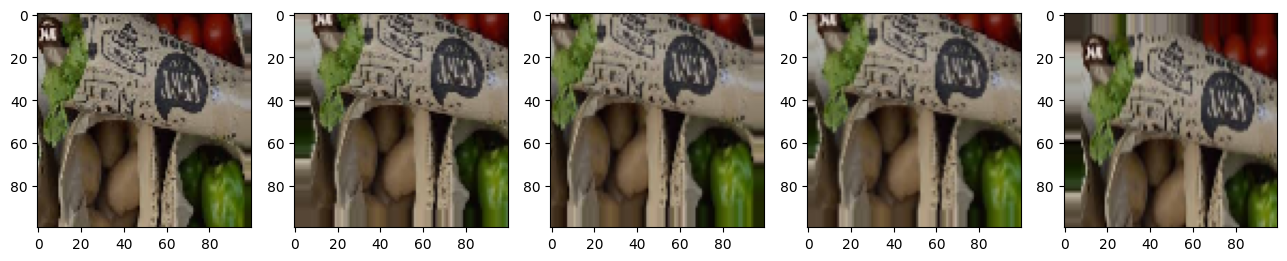

In [85]:
from pathlib import Path

IMG_DIM = (100, 100)

train_files = glob.glob('./o-vs-r-split/train/O/*')
train_files = train_files[:20]
train_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in train_files]
train_imgs = np.array(train_imgs)
train_labels = [Path(fn).parent.name for fn in train_files]

img_id = 0
O_generator = train_datagen.flow(train_imgs[img_id:img_id+1], train_labels[img_id:img_id+1],
                                   batch_size=1)
O = [next(O_generator) for i in range(0,5)]
fig, ax = plt.subplots(1,5, figsize=(16, 6))
print('Labels:', [item[1][0] for item in O])
l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]

Pre-trained Models
Pre-trained models are saved networks that have previously been trained on some large datasets. They are typically used for large-scale image-classification task. They can be used as they are or could be customized to a given task using transfer learning. These pre-trained models form the basis of transfer learning.

VGG-16
Let us load the VGG16 model.

In [86]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)

We flatten the output of a vgg model and assign it to the model output, we then use a Model object basemodel to group the layers into an object for training and inference . With the following inputs and outputs

inputs: vgg.input

outputs: tf.keras.layers.Flatten()(output)

In [87]:
output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

Next, you freeze the basemodel.

In [88]:
for layer in basemodel.layers:
    layer.trainable = False

Create a new model on top. You add a Dropout layer for regularization, only these layers will change as for the lower layers you set training=False when calling the base model.

In [89]:
input_shape = basemodel.output_shape[1]

model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

Task 4: Print the summary of the model Upload the screenshot of the code and output of the summary of the model model_summary.png.

Hint: Use model.summary() to print the summary of the model.

In [90]:
print("Model Summary:")
model.summary()


Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ functional_1 (Functional)            │ (None, 8192)                │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Task 5: Compile the model¶
Upload the screenshot of the code as model_compile.png.

You will compile the model using the following parameters:

loss: 'binary_crossentropy'.
optimizer: optimizers.RMSprop(learning_rate=1e-4).
metrics: ['accuracy'].
Hint: Use model.compile() to compile the model:

model.compile(
    loss=,
    optimizer=,
    metrics=
)

In [91]:
from tensorflow.keras import optimizers

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

print("Model compiled successfully.")


Model compiled successfully.


You will use early stopping to avoid over-training the model.

In [92]:
from tensorflow.keras.callbacks import LearningRateScheduler


checkpoint_path='O_R_tlearn_vgg16.keras'

# define step decay function
class LossHistory_(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.lr = []

    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        self.lr.append(exp_decay(epoch))
        print('lr:', exp_decay(len(self.losses)))

def exp_decay(epoch):
    initial_lrate = 1e-4
    k = 0.1
    lrate = initial_lrate * np.exp(-k*epoch)
    return lrate

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss',
                    patience = 4,
                    mode = 'min',
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

Fit & train the Model

In [93]:
extract_feat_model = model.fit(train_generator,
                               steps_per_epoch=5,
                               epochs=10,
                               callbacks = callbacks_list_,
                               validation_data=val_generator,
                               validation_steps=val_generator.samples // batch_size,
                               verbose=1)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4579 - loss: 0.7674lr: 9.048374180359596e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 93s 19s/step - accuracy: 0.4681 - loss: 0.7627 - val_accuracy: 0.6615 - val_loss: 0.5855 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7107 - loss: 0.5629lr: 8.187307530779819e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 141s 33s/step - accuracy: 0.7110 - loss: 0.5641 - val_accuracy: 0.7031 - val_loss: 0.5291 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7936 - loss: 0.4993lr: 7.408182206817179e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 18s/step - accuracy: 0.7937 - loss: 0.4958 - val_accuracy: 0.7969 - val_loss: 0.4658 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7324 - loss: 0.5396lr: 6.703200460356394e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 82s 19s/step - accuracy: 0.7332 - loss: 0.5377 - val_accuracy: 0.7917 - val_loss: 0.4407 - learning_rate: 7.4082e-05
Epoch 5

Plot loss curves for training and validation sets (extract_feat_model)

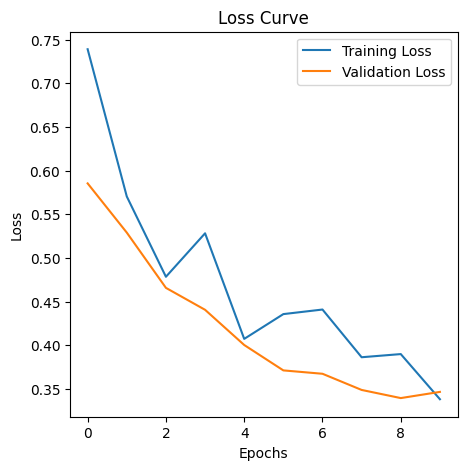

In [95]:
import matplotlib.pyplot as plt

history = extract_feat_model

# plot loss curve
plt.figure(figsize=(5, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Task 6: Plot accuracy curves for training and validation sets (extract_feat_model)
Upload the screenshot of the code and the output of the plot accuracy curve as plot_accuracy_curve.png.

Hint: Similar to the loss curves. Use plt.plot() to plot the accuracy curves for training and validation sets.

figsize=(5, 5)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
Title: 'Accuracy Curve'
xlabel: 'Epochs'
ylabel: 'Accuracy'
NOTE: As training is a stochastic process, the loss and accuracy graphs may differ across runs. As long as the general trend shows decreasing loss and increasing accuracy, the model is performing as expected and full marks will be awarded for the task.

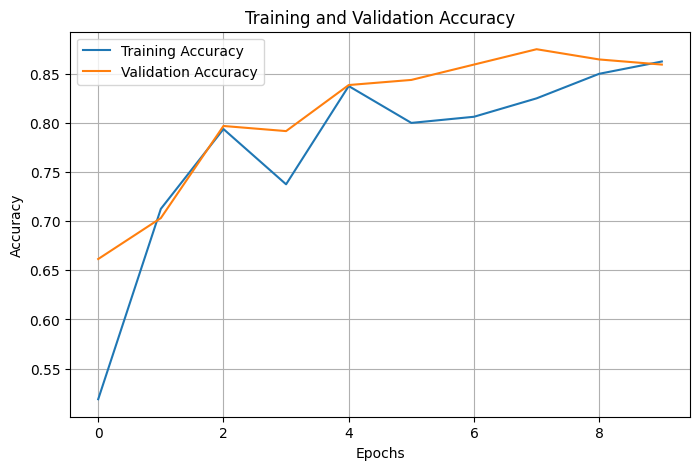

In [96]:
import matplotlib.pyplot as plt

# Extract accuracy data from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training & validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()
plt.show()


Fine-Tuning model
Fine-tuning is an optional step in transfer learning, it usually ends up improving the performance of the model.

You will unfreeze one layer from the base model and train the model again.

In [97]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)

output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

for layer in basemodel.layers:
    layer.trainable = False

display([layer.name for layer in basemodel.layers])

set_trainable = False

for layer in basemodel.layers:
    if layer.name in ['block5_conv3']:
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in basemodel.layers:
    print(f"{layer.name}: {layer.trainable}")

['input_layer_4',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_pool',
 'flatten_1']

input_layer_4: False
block1_conv1: False
block1_conv2: False
block1_pool: False
block2_conv1: False
block2_conv2: False
block2_pool: False
block3_conv1: False
block3_conv2: False
block3_conv3: False
block3_pool: False
block4_conv1: False
block4_conv2: False
block4_conv3: False
block4_pool: False
block5_conv1: False
block5_conv2: False
block5_conv3: True
block5_pool: True
flatten_1: True


Similar to what you did before, you will create a new model on top, and add a Dropout layer for regularization.

In [98]:
model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

checkpoint_path='O_R_tlearn_fine_tune_vgg16.keras'

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss',
                    patience = 4,
                    mode = 'min',
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

fine_tune_model = model.fit(train_generator,
                    steps_per_epoch=5,
                    epochs=10,
                    callbacks = callbacks_list_,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // batch_size,
                    verbose=1)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6204 - loss: 0.6766lr: 9.048374180359596e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 85s 19s/step - accuracy: 0.6243 - loss: 0.6730 - val_accuracy: 0.6146 - val_loss: 0.6832 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6724 - loss: 0.6737lr: 8.187307530779819e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 154s 36s/step - accuracy: 0.6801 - loss: 0.6536 - val_accuracy: 0.8333 - val_loss: 0.3883 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8049 - loss: 0.4444lr: 7.408182206817179e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 134s 31s/step - accuracy: 0.8020 - loss: 0.4452 - val_accuracy: 0.8385 - val_loss: 0.3455 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8391 - loss: 0.3486lr: 6.703200460356394e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 19s/step - accuracy: 0.8346 - loss: 0.3525 - val_accuracy: 0.7917 - val_loss: 0.4221 - learning_rate: 7.4082e-05
Epoch 

Task 7: Plot loss curves for training and validation sets (fine tune model)
Upload the screenshot of the code and the output of the plot loss curves as plot_loss_curve.png.

Hint: Use plt.plot() to plot the loss curves for training and validation sets.

history = fine_tune_model
figsize=(5, 5)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
Title: 'Loss Curve'
xlabel: 'Epochs'
ylabel: 'Loss'
NOTE: As training is a stochastic process, the loss and accuracy graphs may differ across runs. As long as the general trend shows decreasing loss and increasing accuracy, the model is performing as expected and full marks will be awarded for the task.

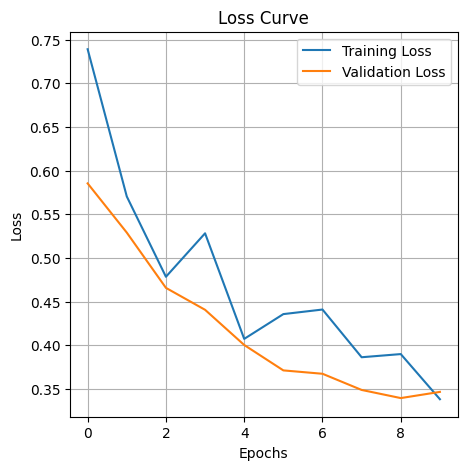

In [100]:
import matplotlib.pyplot as plt

# Extract loss data from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot training & validation loss
plt.figure(figsize=(5, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()
plt.show()


Task 8: Plot accuracy curves for training and validation sets (fine tune model)
Upload the screenshot of the code and the plot accuracy curve for the fine-tune model as plot_finetune_model.png.

Hint: Similar to the loss curves. Use plt.plot() to plot the accuracy curves for training and validation sets.

history = fine_tune_model
figsize=(5, 5)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
Title: 'Accuracy Curve'
xlabel: 'Epochs'
ylabel: 'Accuracy'
NOTE: As training is a stochastic process, the loss and accuracy graphs may differ across runs. As long as the general trend shows decreasing loss and increasing accuracy, the model is performing as expected and full marks will be awarded for the task.

In [ ]:
history = fine_tune_model

# Task 8: Plot accuracy curves for training and validation sets  (fine tune model)

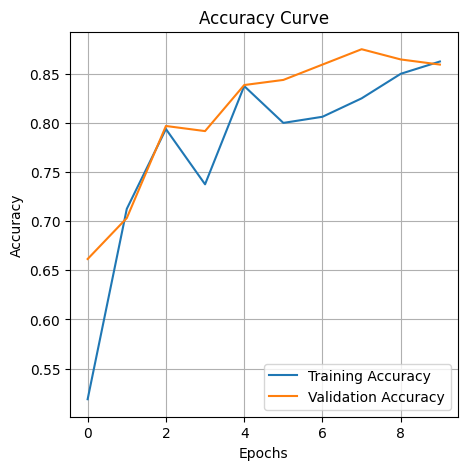

In [101]:
import matplotlib.pyplot as plt

# Extract accuracy data from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training & validation accuracy
plt.figure(figsize=(5, 5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()
plt.show()


Evaluate both models on test data¶
Load saved models
Load test images
Make predictions for both models
Convert predictions to class labels
Print classification report for both models

In [102]:
from pathlib import Path

# Load saved models
extract_feat_model = tf.keras.models.load_model('O_R_tlearn_vgg16.keras')
fine_tune_model = tf.keras.models.load_model('O_R_tlearn_fine_tune_vgg16.keras')

IMG_DIM = (150, 150)

# Load test images
test_files_O = glob.glob('./o-vs-r-split/test/O/*')
test_files_R = glob.glob('./o-vs-r-split/test/R/*')
test_files = test_files_O[:50] + test_files_R[:50]

test_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in test_files]
test_imgs = np.array(test_imgs)
test_labels = [Path(fn).parent.name for fn in test_files]

# Standardize
test_imgs_scaled = test_imgs.astype('float32')
test_imgs_scaled /= 255

class2num_lt = lambda l: [0 if x == 'O' else 1 for x in l]
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]

test_labels_enc = class2num_lt(test_labels)

# Make predictions for both models
predictions_extract_feat_model = extract_feat_model.predict(test_imgs_scaled, verbose=0)
predictions_fine_tune_model = fine_tune_model.predict(test_imgs_scaled, verbose=0)

# Convert predictions to class labels
predictions_extract_feat_model = num2class_lt(predictions_extract_feat_model)
predictions_fine_tune_model = num2class_lt(predictions_fine_tune_model)

# Print classification report for both models
print('Extract Features Model')
print(metrics.classification_report(test_labels, predictions_extract_feat_model))
print('Fine-Tuned Model')
print(metrics.classification_report(test_labels, predictions_fine_tune_model))

Extract Features Model
              precision    recall  f1-score   support

           O       0.84      0.86      0.85        50
           R       0.86      0.84      0.85        50

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.85      0.85      0.85       100

Fine-Tuned Model
              precision    recall  f1-score   support

           O       0.80      0.86      0.83        50
           R       0.85      0.78      0.81        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



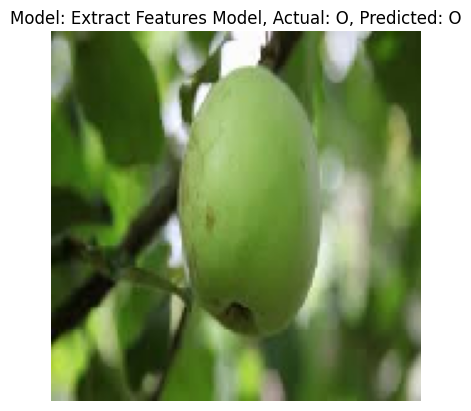

In [103]:
# Plot one of the images with actual label and predicted label as title
def plot_image_with_title(image, model_name, actual_label, predicted_label):
    plt.imshow(image)
    plt.title(f"Model: {model_name}, Actual: {actual_label}, Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

# Specify index of image to plot, for example index 0
index_to_plot = 0
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Extract Features Model',
    actual_label=test_labels[index_to_plot],
    predicted_label=predictions_extract_feat_model[index_to_plot],
    )

Task 9: Plot a test image using Extract Features Model (index_to_plot = 1)
Upload the screenshot of the code and the extract features model as extract_features_model.png.

Instructions:

Use plot_image_with_title function.
index_to_plot = 1
model_name='Extract Features Model'
predicted_label=predictions_extract_feat_model[index_to_plot]
Hint: Follow the same format as previous plots.

NOTE: Due to the inherent nature of neural networks, predictions may vary from the actual labels. For instance, if the actual label is ‘O’, the prediction could be either ‘O’ or ‘R’, both of which are possible outcomes, and full marks will be awarded for the task.

In [ ]:
# Task 9: Plot a test image using Extract Features Model (index_to_plot = 1)

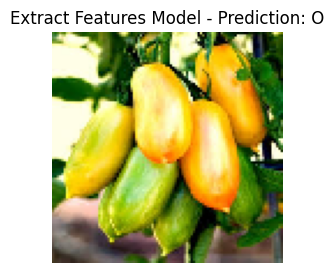

In [107]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image_with_title(img, title):
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Set index of the test image to plot
index_to_plot = 1

# Get the image from the test dataset
test_img, _ = test_generator[index_to_plot]  # Extracting image batch
img = test_img[0]  # Selecting the first image in the batch

# Get the predicted label
predicted_label = predictions_extract_feat_model[index_to_plot]

# Plot the image with title
plot_image_with_title(img, f'Extract Features Model - Prediction: {predicted_label}')


Task 10: Plot a test image using Fine-Tuned Model (index_to_plot = 1)
Upload the screenshot of the code and the fine-tuned model as finetuned_model.png.

Instructions:

Use plot_image_with_title function.
index_to_plot = 1
model_name='Fine-Tuned Model'
predicted_label=predictions_fine_tune_model[index_to_plot]
Hint: follow the same format as previous plots.

NOTE: Due to the inherent nature of neural networks, predictions may vary from the actual labels. For instance, if the actual label is ‘O’, the prediction could be either ‘O’ or ‘R’, both of which are possible outcomes, and full marks will be awarded for the task.

In [ ]:
# Task 10: Plot a test image using Fine-Tuned Model (index_to_plot = 1)

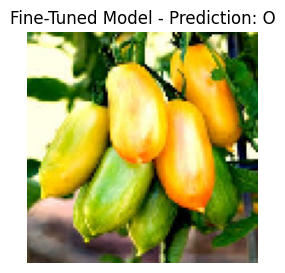

In [108]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image_with_title(img, title):
    """Function to display an image with a title."""
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Set index of the test image to plot
index_to_plot = 1

# Get the image and label from the test dataset
test_img, _ = test_generator[index_to_plot]  # Extract batch
img = test_img[0]  # Selecting the first image in the batch

# Get the predicted label from the Fine-Tuned Model
predicted_label = predictions_fine_tune_model[index_to_plot]

# Plot the image with title
plot_image_with_title(img, f'Fine-Tuned Model - Prediction: {predicted_label}')
